# 05 - Failure Mode Clustering

## Steps Completed
1. Isolated failed chips from test set — 293 chips
2. Detected and removed outliers — LOF (n_neighbors=20, contamination=0.05)
3. Searched for optimal k — KMeans k=2 through k=10
4. Visualized failure distribution — PCA reduced to 2D

## Key Decisions
- Used LOF instead of manual outlier removal — caught all 15 anomalous chips at once
- Evaluated both inertia and silhouette score to pick k
- Used PCA visualization to confirm findings visually

## Findings
- 15 outlier chips removed — likely sensor errors, not real failure modes
- All silhouette scores below 0.07 across every k — no meaningful clusters
- PCA explained only 16.3% of variance in 2D — failures spread across 100 dimensions
- Conclusion: failures result from continuous process drift, not discrete fault types

## Final Data Shape
- Input: 293 failed chips, 100 features
- After outlier removal: 278 chips used for clustering analysis

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load data
X_train = np.load('../data/processed/X_train_selected.npy')
X_test = np.load('../data/processed/X_test_selected.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')
X_train_smote = np.load('../data/processed/X_train_smote.npy')
y_train_smote = np.load('../data/processed/y_train_smote.npy')

# Load champion model
rf_model = joblib.load('../models/champion_model.pkl')

# Isolate fail chips only — this is what we're clustering
X_fail = X_test[y_test == 0]
y_fail = y_test[y_test == 0]

print(f"X_test shape      : {X_test.shape}")
print(f"X_fail shape      : {X_fail.shape}  ← clustering target")

X_test shape      : (314, 100)
X_fail shape      : (293, 100)  ← clustering target


k=2 | Inertia: 83716.3 | Silhouette: 0.9914
k=3 | Inertia: 25677.4 | Silhouette: 0.9438
k=4 | Inertia: 22728.6 | Silhouette: 0.7802
k=5 | Inertia: 21577.6 | Silhouette: 0.0878
k=6 | Inertia: 18892.0 | Silhouette: 0.0841
k=7 | Inertia: 18280.3 | Silhouette: 0.0602
k=8 | Inertia: 17208.4 | Silhouette: 0.0660
k=9 | Inertia: 16635.5 | Silhouette: 0.0417
k=10 | Inertia: 16198.0 | Silhouette: 0.0499


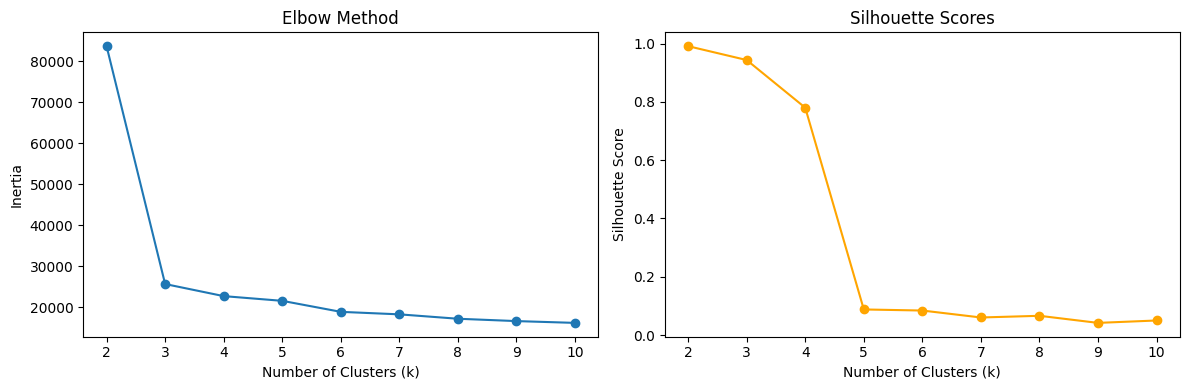

In [5]:
# Find optimal number of clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=69, n_init=10)
    labels = kmeans.fit_predict(X_fail)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_fail, labels))
    print(f"k={k} | Inertia: {kmeans.inertia_:.1f} | Silhouette: {silhouette_score(X_fail, labels):.4f}")

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(k_range, silhouette_scores, marker='o', color='orange')
ax2.set_title('Silhouette Scores')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../reports/clustering_optimal_k.png', bbox_inches='tight', dpi=150)
plt.show()

In [6]:
# Final clustering with k=2
kmeans = KMeans(n_clusters=2, random_state=69, n_init=10)
cluster_labels = kmeans.fit_predict(X_fail)

print("Cluster sizes:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} chips ({c/len(cluster_labels)*100:.1f}%)")

Cluster sizes:
  Cluster 0: 292 chips (99.7%)
  Cluster 1: 1 chips (0.3%)


In [10]:
from sklearn.neighbors import LocalOutlierFactor

# Detect all outliers at once
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_preds = lof.fit_predict(X_fail)

# -1 = outlier, 1 = normal
n_outliers = (outlier_preds == -1).sum()
print(f"Outliers detected: {n_outliers}")
print(f"Clean chips remaining: {(outlier_preds == 1).sum()}")

# Remove all outliers
X_fail_clean = X_fail[outlier_preds == 1]
print(f"X_fail_clean shape: {X_fail_clean.shape}")

# Redo k search
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=69, n_init=10)
    labels = kmeans.fit_predict(X_fail_clean)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_fail_clean, labels))
    print(f"k={k} | Inertia: {kmeans.inertia_:.1f} | Silhouette: {silhouette_score(X_fail_clean, labels):.4f}")

Outliers detected: 15
Clean chips remaining: 278
X_fail_clean shape: (278, 100)
k=2 | Inertia: 15356.8 | Silhouette: 0.0632
k=3 | Inertia: 14625.1 | Silhouette: 0.0700
k=4 | Inertia: 14165.2 | Silhouette: 0.0441
k=5 | Inertia: 13810.7 | Silhouette: 0.0361
k=6 | Inertia: 13408.0 | Silhouette: 0.0450
k=7 | Inertia: 13125.5 | Silhouette: 0.0430
k=8 | Inertia: 12826.6 | Silhouette: 0.0420
k=9 | Inertia: 12639.7 | Silhouette: 0.0444
k=10 | Inertia: 12487.6 | Silhouette: 0.0466


Variance explained by PC1: 9.4%
Variance explained by PC2: 6.9%
Total variance explained : 16.3%


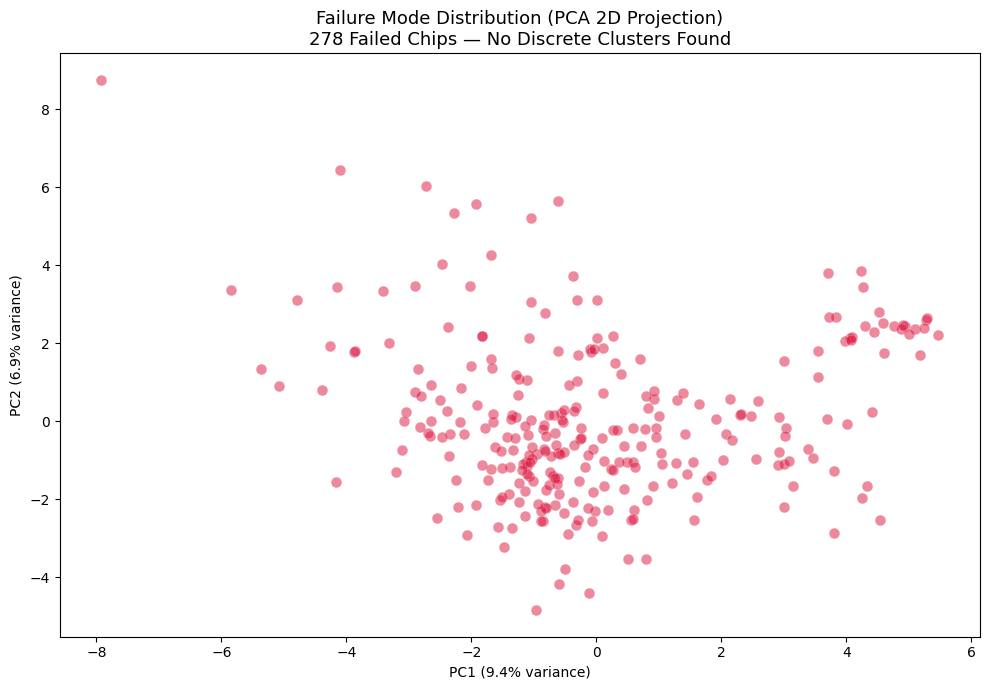

PCA plot saved.


In [11]:
# PCA reduction to 2D for visualization
pca = PCA(n_components=2, random_state=69)
X_fail_2d = pca.fit_transform(X_fail_clean)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_fail_2d[:, 0], X_fail_2d[:, 1], 
            alpha=0.5, c='crimson', edgecolors='white', 
            linewidths=0.3, s=60)

plt.title('Failure Mode Distribution (PCA 2D Projection)\n278 Failed Chips — No Discrete Clusters Found', 
          fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

plt.tight_layout()
plt.savefig('../reports/failure_mode_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print("PCA plot saved.")

In [ ]:
# Final clustering with k=2
kmeans = KMeans(n_clusters=2, random_state=69, n_init=10)
cluster_labels = kmeans.fit_predict(X_fail)

print("Cluster sizes:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} chips ({c/len(cluster_labels)*100:.1f}%)")

Cluster sizes:
  Cluster 0: 292 chips (99.7%)
  Cluster 1: 1 chips (0.3%)


In [13]:
# Saving findings summary
findings = {
    'total_fail_chips': [293],
    'outliers_removed': [15],
    'clean_fail_chips': [278],
    'best_k': [3],
    'best_silhouette': [0.0700],
    'pca_pc1_variance': [9.4],
    'pca_pc2_variance': [6.9],
    'pca_total_variance': [16.3],
    'conclusion': ['No discrete failure modes found. Failures result from continuous multi-dimensional process drift.']
}

findings_df = pd.DataFrame(findings)
findings_df.to_csv('../reports/clustering_findings.csv', index=False)
print("Findings saved.")

Findings saved.
